In [1]:
import numpy as np
import scvelo as scv
import scanpy as sc
import pandas as pd
import topovelo as tpv
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = ''
DATA_NAME = 'thymus-ped'

In [3]:
adata = sc.read_h5ad(f'{DATA_DIR}/{DATA_NAME}-out.h5ad')

# 1. Cell Velocity and Inferred Cell Time

Overwriting the original KNN graph! (.uns, .obsp)


---   Plotting  Results   ---
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/32 cores)


  0%|          | 0/2165 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'gcn_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gcn_velocity_spatial', embedded velocity vectors (adata.obsm)


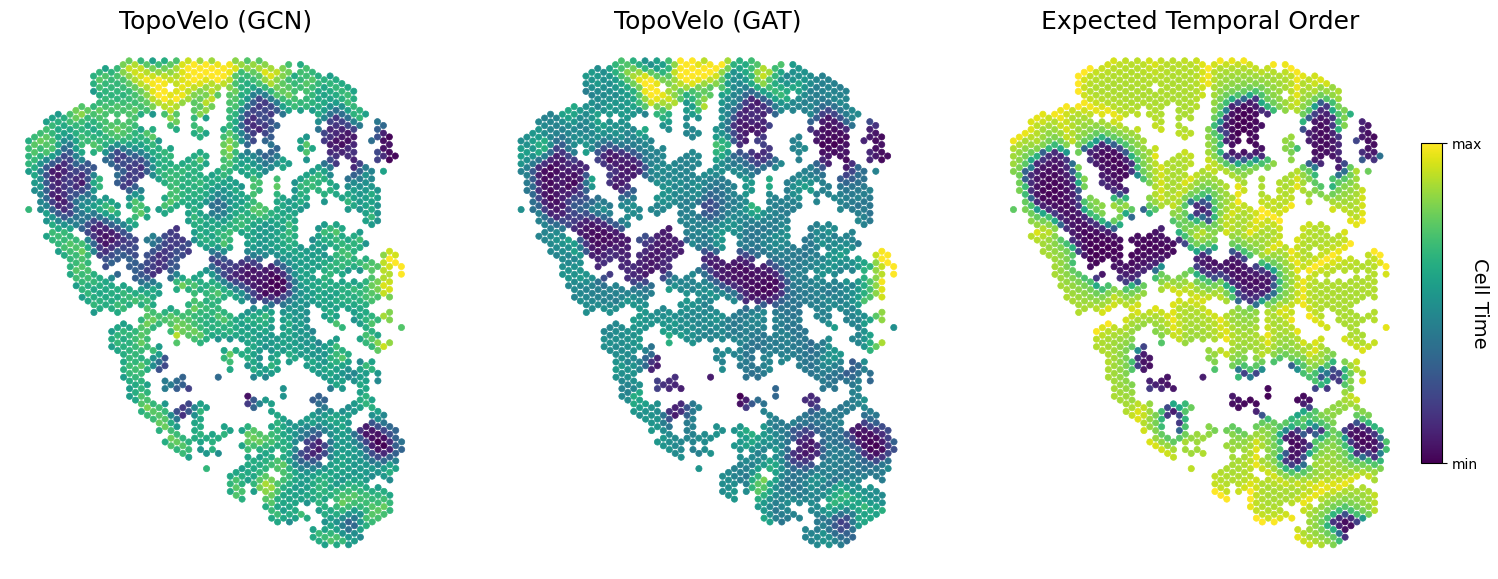

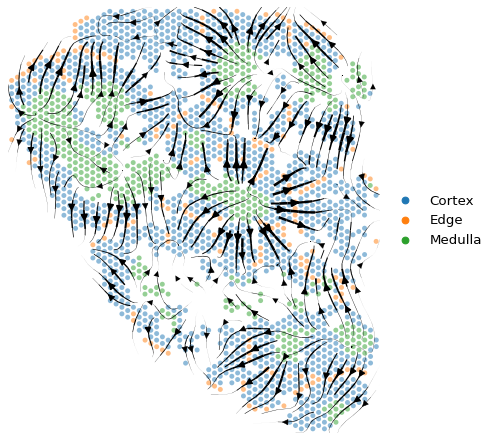

Overwriting the original KNN graph! (.uns, .obsp)


Recovering the original KNN graph from .uns
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/32 cores)


  0%|          | 0/2165 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_spatial', embedded velocity vectors (adata.obsm)


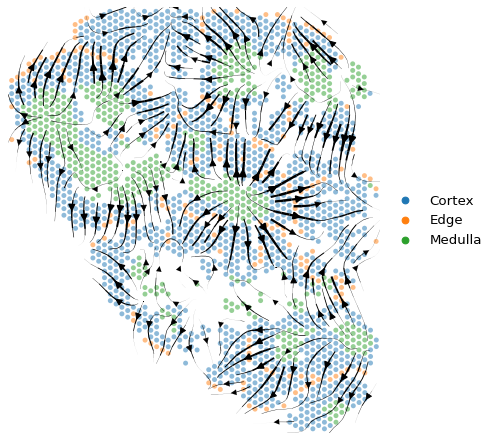

Recovering the original KNN graph from .uns


(None, None, None, None)

In [4]:
tpv.post_analysis(
    adata,
    'thymus-ped',
    ['TopoVelo (GCN)', 'TopoVelo (GAT)'],
    ['gcn', 'gat'],
    compute_metrics=False,
    plot_type=['time', 'cell velocity'],
    plot_basis='spatial',
)

# Velocity on UMAP

In [6]:
scv.tl.umap(adata, min_dist=0.25)

---   Plotting  Results   ---
computing velocity graph (using 1/32 cores)


  0%|          | 0/2165 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'gcn_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gcn_velocity_umap', embedded velocity vectors (adata.obsm)


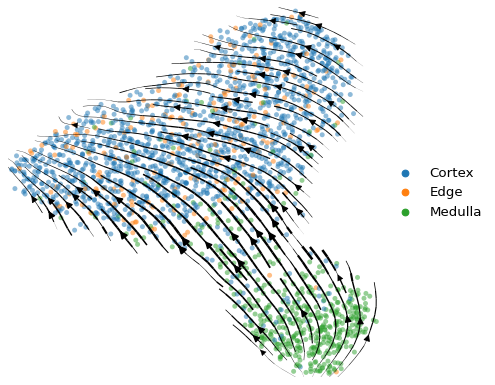

computing velocity graph (using 1/32 cores)


  0%|          | 0/2165 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_umap', embedded velocity vectors (adata.obsm)


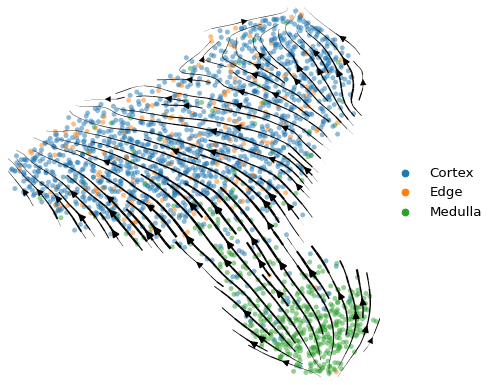

(None, None, None, None)

In [9]:
tpv.post_analysis(
    adata,
    'thymus-ped',
    ['TopoVelo (GCN)', 'TopoVelo (GAT)'],
    ['gcn', 'gat'],
    compute_metrics=False,
    plot_type=['embed velocity'],
    plot_basis='umap',
)

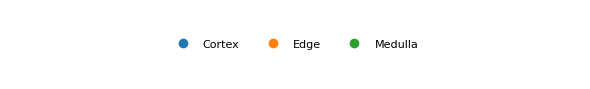

In [10]:
tpv.plotting.DPI = 300
tpv.plotting.plot_legend(adata, 'clusters', ncol=3, fontsize=8, save="")